# Road Crack Detection Model
##### Component 1: Crack Segmentation Model

This notebook is part of a multi-component crack detection pipeline for MOP project.

**My Role (Team Member 1):** Build the AI model that detects cracks in images and outputs binary crack masks — the foundation for all downstream components (crack metrics, RAG + LLM reporting, Streamlit interface).

**Pipeline:**
`Image → Crack Detection Model → Crack Mask → Crack Metrics → LLM Report`

**Approach:** Compare UNet + ResNet34 vs DeepLabV3+ + ResNet50 to select the best segmentation architecture and improve the performance.
**Dataset:** [Crack Segmentation Dataset](https://www.kaggle.com/datasets/lakshaymiddha/crack-segmentation-dataset)  
**Metrics:** IoU & Dice Score

## 1. Imports

In [2]:
pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [3]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

## 2. Environment Setup

In [4]:
SAVE_DIR = "/content/outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

## ⚡ Quick Start — Loading Models from Drive (No Retraining)

If your session restarted and you want to **skip retraining**, run only these cells in order:

1. **Cell: pip install** (install segmentation-models-pytorch)
2. **Cell: Imports**
3. **Cell: SAVE_DIR**
4. **Cell: Load models from Drive** ← copies .pth files to /content/outputs
5. **Cell: Kaggle credentials + Dataset download** ← needed for val_images
6. **Cell: Dataset Preparation** (image_dir, train/val split)
7. **Cell: Transforms**
8. **Cell: Dataset Class**
9. **Cell: DataLoaders**
10. **Cell: Metric Functions**
11. **Cell: device** (first line of training function cell — just run the whole cell, it only defines the function)
12. **Cell: Best model path** ← hardcoded, no training needed
13. **Cell: Load best model**
14. **Cell: predict_mask()**
15. **Cell: Visual check**
16. **Cell: pip install supabase**
17. **Cell: Supabase setup**
18. **Cell: upload_to_bucket() + push_inference_result()**
19. **Cell: run_pipeline()**

Skip everything marked `# ── SKIP THIS CELL WHEN LOADING FROM DRIVE`


In [5]:
# ── RUN THIS ONLY IF SESSION RESTARTED — skip if you want to train models ───────────
# Update the Drive paths below to match where YOU saved the models in your Google Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(
    "/content/drive/MyDrive/crack_detection/model1_unet_resnet34.pth",
    os.path.join(SAVE_DIR, "model1_unet_resnet34.pth")
)
shutil.copy(
    "/content/drive/MyDrive/crack_detection/model2_deeplabv3plus_resnet50.pth",
    os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth")
)
print("Models loaded from Google Drive!")

Mounted at /content/drive
Models loaded from Google Drive!


In [6]:
# ── Add your Kaggle credentials here ────────────────────────────────────────
# Get your kaggle.json from https://www.kaggle.com/settings and paste below
kaggle_username = "your_kaggle_username"
kaggle_key      = "your_kaggle_key"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials set!")

Kaggle credentials set!


In [7]:
!pip install kaggle -q
!kaggle datasets download -d lakshaymiddha/crack-segmentation-dataset -q
print("Download done!")
!unzip -q crack-segmentation-dataset.zip
print("Unzip done!")

Dataset URL: https://www.kaggle.com/datasets/lakshaymiddha/crack-segmentation-dataset
License(s): unknown
Download done!
Unzip done!


## 3. Dataset Preparation

In [8]:
image_dir = "crack_segmentation_dataset/train/images"
mask_dir  = "crack_segmentation_dataset/train/masks"

image_files = [f for f in os.listdir(image_dir)
               if not f.startswith('non_crack') and
               f.lower().endswith(('.jpg', '.png'))]

print("Total images:", len(image_files))

Total images: 9603


In [9]:
train_images, val_images = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))

Train images: 7682
Validation images: 1921


## 4. Transforms

In [10]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Dataset Class & DataLoaders

In [13]:
class CrackDataset(Dataset):

    def __init__(self, image_dir, mask_dir, image_list, transform=None):
        self.transform = transform
        self.images    = []
        self.masks     = []
        skipped        = 0

        for img_name in image_list:
            image_path = os.path.join(image_dir, img_name)
            mask_path  = os.path.join(mask_dir,  img_name)

            image = cv2.imread(image_path)
            mask  = cv2.imread(mask_path, 0)

            if image is None or mask is None:
                skipped += 1
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask[mask > 0] = 1

            self.images.append(image)
            self.masks.append(mask)

        print(f"Valid pairs: {len(self.images)} | Skipped: {skipped} | Cached in memory ✓")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask  = self.masks[idx]

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image     = augmented["image"]
            mask      = augmented["mask"]

        return image.float(), mask.unsqueeze(0).float()

In [14]:
train_dataset = CrackDataset(image_dir, mask_dir, train_images, transform=train_transform)
val_dataset   = CrackDataset(image_dir, mask_dir, val_images,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Sanity check
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask  batch shape:", masks.shape)

Valid pairs: 7682 | Skipped: 0 | Cached in memory ✓
Valid pairs: 1921 | Skipped: 0 | Cached in memory ✓
Image batch shape: torch.Size([32, 3, 224, 224])
Mask  batch shape: torch.Size([32, 1, 224, 224])


## 6. Sample Visualisation

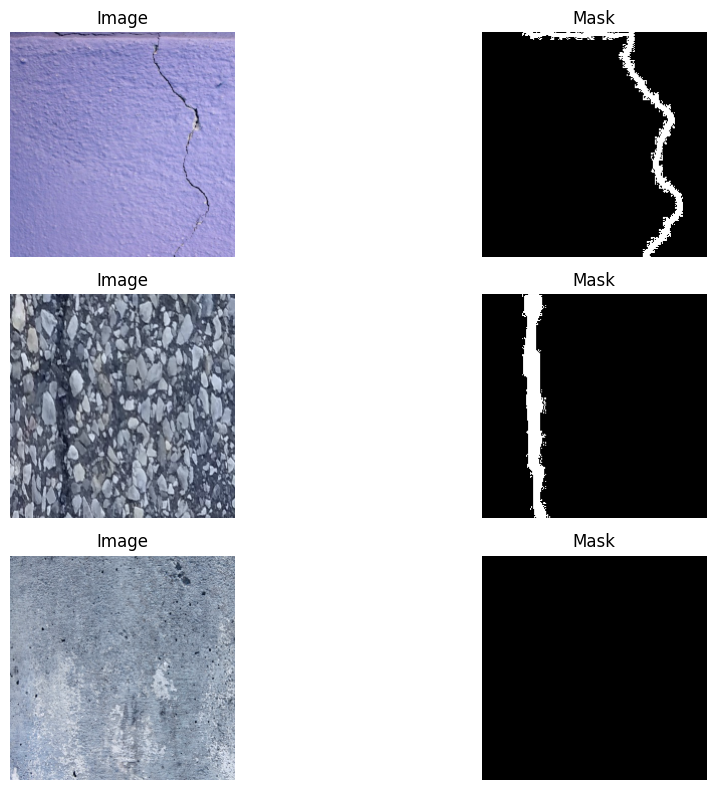

In [15]:
plt.figure(figsize=(12, 8))
images, masks = next(iter(train_loader))

for i in range(3):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(img); plt.title("Image"); plt.axis("off")

    plt.subplot(3, 2, 2*i+2)
    plt.imshow(masks[i].cpu().squeeze(), cmap="gray"); plt.title("Mask"); plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Metric Functions

In [16]:
def iou_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    intersection = (pred * mask).sum(dim=dims)
    union = pred.sum(dim=dims) + mask.sum(dim=dims) - intersection
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()

def dice_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    intersection = (pred * mask).sum(dim=dims)
    return ((2 * intersection + 1e-6) / (pred.sum(dim=dims) + mask.sum(dim=dims) + 1e-6)).mean().item()

def precision_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    tp = (pred * mask).sum(dim=dims)
    fp = pred.sum(dim=dims) - tp
    return ((tp + 1e-6) / (tp + fp + 1e-6)).mean().item()

def recall_score(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    dims = (1, 2, 3)
    tp = (pred * mask).sum(dim=dims)
    fn = mask.sum(dim=dims) - tp
    return ((tp + 1e-6) / (tp + fn + 1e-6)).mean().item()

## 8. Training Function

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_model(model, train_loader, val_loader, num_epochs=15, lr=0.0001, save_path=None):
    model.to(device)
    loss_fn   = smp.losses.DiceLoss(mode="binary")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_ious, val_dices, val_precisions, val_recalls = [], [], [], [], [], []

    best_dice = 0.0

    for epoch in range(num_epochs):
        # Train
        model.train()
        epoch_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss  = loss_fn(preds, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()

        # Validate
        model.eval()
        val_loss = val_iou = val_dice = val_prec = val_rec = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs  = model(images)
                val_loss += loss_fn(outputs, masks).item()
                val_iou  += iou_score(outputs, masks)
                val_dice += dice_score(outputs, masks)
                val_prec += precision_score(outputs, masks)
                val_rec  += recall_score(outputs, masks)

        train_losses.append(epoch_loss  / len(train_loader))
        val_losses.append(val_loss      / len(val_loader))
        val_ious.append(val_iou         / len(val_loader))
        val_dices.append(val_dice       / len(val_loader))
        val_precisions.append(val_prec  / len(val_loader))
        val_recalls.append(val_rec      / len(val_loader))

        current_dice = val_dices[-1]

        print(f"Epoch {epoch+1:02d} | Loss: {train_losses[-1]:.4f} | "
              f"IoU: {val_ious[-1]:.4f} | Dice: {current_dice:.4f} | "
              f"Precision: {val_precisions[-1]:.4f} | Recall: {val_recalls[-1]:.4f}")

        # Save best checkpoint
        if current_dice > best_dice:
            best_dice = current_dice
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

    return train_losses, val_losses, val_ious, val_dices, val_precisions, val_recalls

Using device: cuda


## 9. Model 1 — UNet + ResNet34

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
model1 = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
train_losses1, val_losses1, val_ious1, val_dices1, val_precisions1, val_recalls1 = train_model(
    model1, train_loader, val_loader,
    num_epochs=15,
    save_path=os.path.join(SAVE_DIR, "model1_unet_resnet34.pth")
)

Epoch 01 | Loss: 0.7703 | IoU: 0.4769 | Dice: 0.6114 | Precision: 0.5252 | Recall: 0.8612
Epoch 02 | Loss: 0.5266 | IoU: 0.5500 | Dice: 0.6823 | Precision: 0.6204 | Recall: 0.8428
Epoch 03 | Loss: 0.3818 | IoU: 0.5732 | Dice: 0.7026 | Precision: 0.6946 | Recall: 0.7753
Epoch 04 | Loss: 0.3268 | IoU: 0.5826 | Dice: 0.7098 | Precision: 0.7187 | Recall: 0.7623
Epoch 05 | Loss: 0.3111 | IoU: 0.5785 | Dice: 0.7069 | Precision: 0.6950 | Recall: 0.7849
Epoch 06 | Loss: 0.3000 | IoU: 0.5865 | Dice: 0.7136 | Precision: 0.7252 | Recall: 0.7588
Epoch 07 | Loss: 0.2925 | IoU: 0.5941 | Dice: 0.7205 | Precision: 0.7143 | Recall: 0.7893
Epoch 08 | Loss: 0.2859 | IoU: 0.5953 | Dice: 0.7230 | Precision: 0.7025 | Recall: 0.8050
Epoch 09 | Loss: 0.2848 | IoU: 0.5949 | Dice: 0.7213 | Precision: 0.7219 | Recall: 0.7779
Epoch 10 | Loss: 0.2837 | IoU: 0.5980 | Dice: 0.7256 | Precision: 0.7323 | Recall: 0.7693
Epoch 11 | Loss: 0.2817 | IoU: 0.5876 | Dice: 0.7158 | Precision: 0.7319 | Recall: 0.7525
Epoch 12 |

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
torch.save(model1.state_dict(), os.path.join(SAVE_DIR, "model1_unet_resnet34.pth"))

with open(os.path.join(SAVE_DIR, "model1_history.json"), "w") as f:
    json.dump({"train_losses": train_losses1, "val_losses": val_losses1,
               "val_ious": val_ious1, "val_dices": val_dices1}, f)

print("Model 1 saved!")
print(f"Best IoU:  {max(val_ious1):.4f}  (Epoch {val_ious1.index(max(val_ious1))+1})")
print(f"Best Dice: {max(val_dices1):.4f}  (Epoch {val_dices1.index(max(val_dices1))+1})")

Model 1 saved!
Best IoU:  0.6063  (Epoch 15)
Best Dice: 0.7330  (Epoch 15)


In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import shutil
os.makedirs("/content/drive/MyDrive/crack_detection", exist_ok=True)

shutil.copy(
    os.path.join(SAVE_DIR, "model1_unet_resnet34.pth"),
    "/content/drive/MyDrive/crack_detection/model1_unet_resnet34.pth"
)
print("Model 1 saved to Google Drive!")

Mounted at /content/drive
Model 1 saved to Google Drive!


### Model 1 — Training Curves

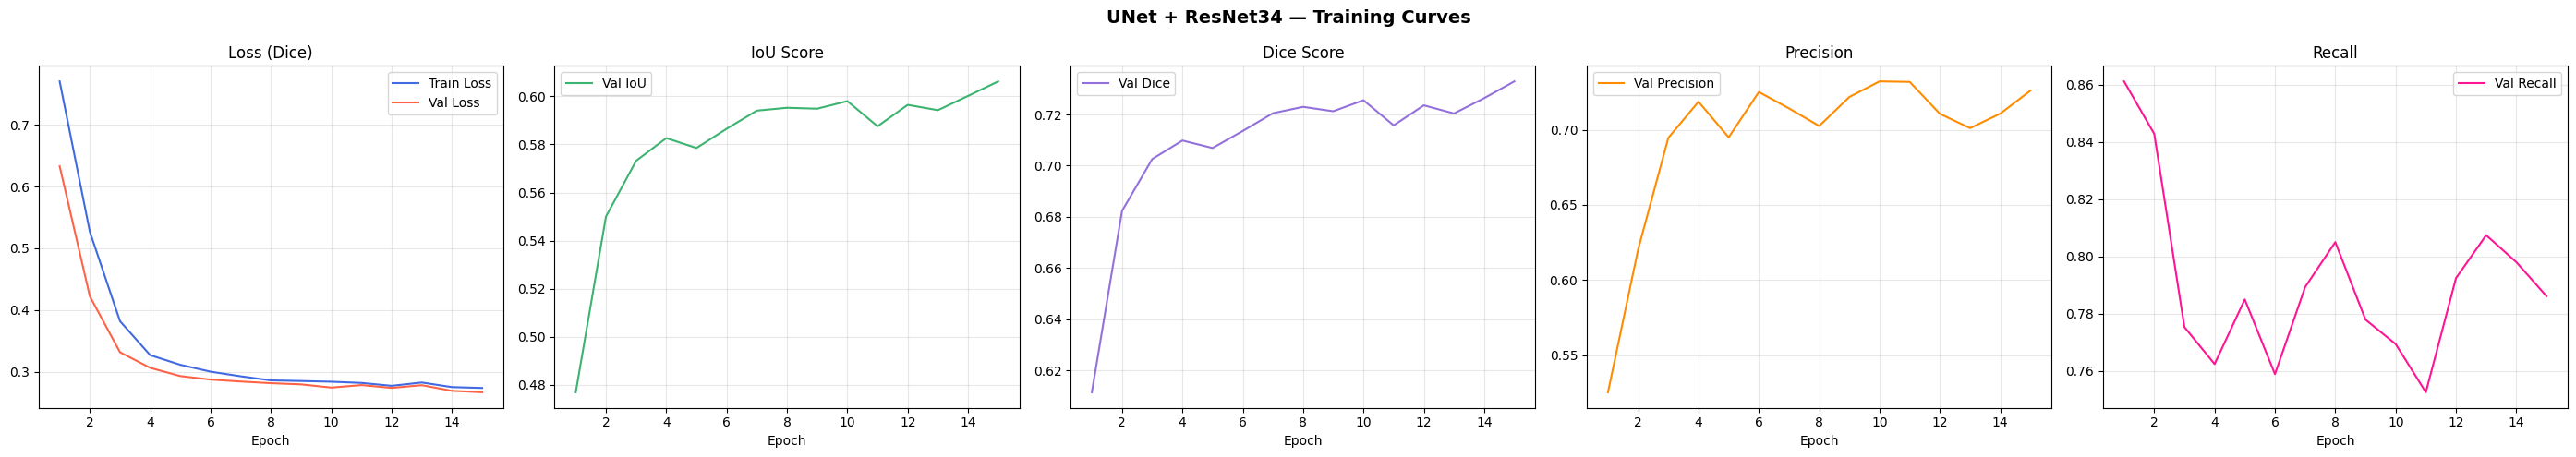

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
epochs1 = range(1, len(train_losses1) + 1)
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle("UNet + ResNet34 — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs1, train_losses1, label="Train Loss", color="royalblue")
axes[0].plot(epochs1, val_losses1,   label="Val Loss",   color="tomato")
axes[0].set_title("Loss (Dice)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs1, val_ious1, label="Val IoU", color="mediumseagreen")
axes[1].set_title("IoU Score"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs1, val_dices1, label="Val Dice", color="mediumpurple")
axes[2].set_title("Dice Score"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(epochs1, val_precisions1, label="Val Precision", color="darkorange")
axes[3].set_title("Precision"); axes[3].set_xlabel("Epoch"); axes[3].legend(); axes[3].grid(alpha=0.3)

axes[4].plot(epochs1, val_recalls1, label="Val Recall", color="deeppink")
axes[4].set_title("Recall"); axes[4].set_xlabel("Epoch"); axes[4].legend(); axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model1_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Model 2 — DeepLabV3+ + ResNet50

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
model2 = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=1)
train_losses2, val_losses2, val_ious2, val_dices2, val_precisions2, val_recalls2 = train_model(
    model2, train_loader, val_loader,
    num_epochs=15,
    save_path=os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth")
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 01 | Loss: 0.6946 | IoU: 0.4933 | Dice: 0.6270 | Precision: 0.5597 | Recall: 0.8239
Epoch 02 | Loss: 0.4110 | IoU: 0.5536 | Dice: 0.6854 | Precision: 0.6571 | Recall: 0.7883
Epoch 03 | Loss: 0.3436 | IoU: 0.5545 | Dice: 0.6831 | Precision: 0.7103 | Recall: 0.7251
Epoch 04 | Loss: 0.3237 | IoU: 0.5769 | Dice: 0.7066 | Precision: 0.6908 | Recall: 0.7800
Epoch 05 | Loss: 0.3111 | IoU: 0.5805 | Dice: 0.7093 | Precision: 0.7053 | Recall: 0.7663
Epoch 06 | Loss: 0.3056 | IoU: 0.5778 | Dice: 0.7070 | Precision: 0.6817 | Recall: 0.7973
Epoch 07 | Loss: 0.2960 | IoU: 0.5859 | Dice: 0.7151 | Precision: 0.6932 | Recall: 0.7904
Epoch 08 | Loss: 0.2934 | IoU: 0.5801 | Dice: 0.7090 | Precision: 0.6898 | Recall: 0.7853
Epoch 09 | Loss: 0.2948 | IoU: 0.5858 | Dice: 0.7137 | Precision: 0.7026 | Recall: 0.7798
Epoch 10 | Loss: 0.2900 | IoU: 0.5852 | Dice: 0.7129 | Precision: 0.7077 | Recall: 0.7714
Epoch 11 | Loss: 0.2887 | IoU: 0.5867 | Dice: 0.7151 | Precision: 0.7075 | Recall: 0.7724
Epoch 12 |

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
torch.save(model2.state_dict(), os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth"))

with open(os.path.join(SAVE_DIR, "model2_history.json"), "w") as f:
    json.dump({"train_losses": train_losses2, "val_losses": val_losses2,
               "val_ious": val_ious2, "val_dices": val_dices2}, f)

print("Model 2 saved!")
print(f"Best IoU:  {max(val_ious2):.4f}  (Epoch {val_ious2.index(max(val_ious2))+1})")
print(f"Best Dice: {max(val_dices2):.4f}  (Epoch {val_dices2.index(max(val_dices2))+1})")

Model 2 saved!
Best IoU:  0.5972  (Epoch 14)
Best Dice: 0.7254  (Epoch 14)


In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
shutil.copy(
    os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth"),
    "/content/drive/MyDrive/crack_detection/model2_deeplabv3plus_resnet50.pth"
)
print("Model 2 saved to Google Drive!")

Model 2 saved to Google Drive!


### Model 2 — Training Curves

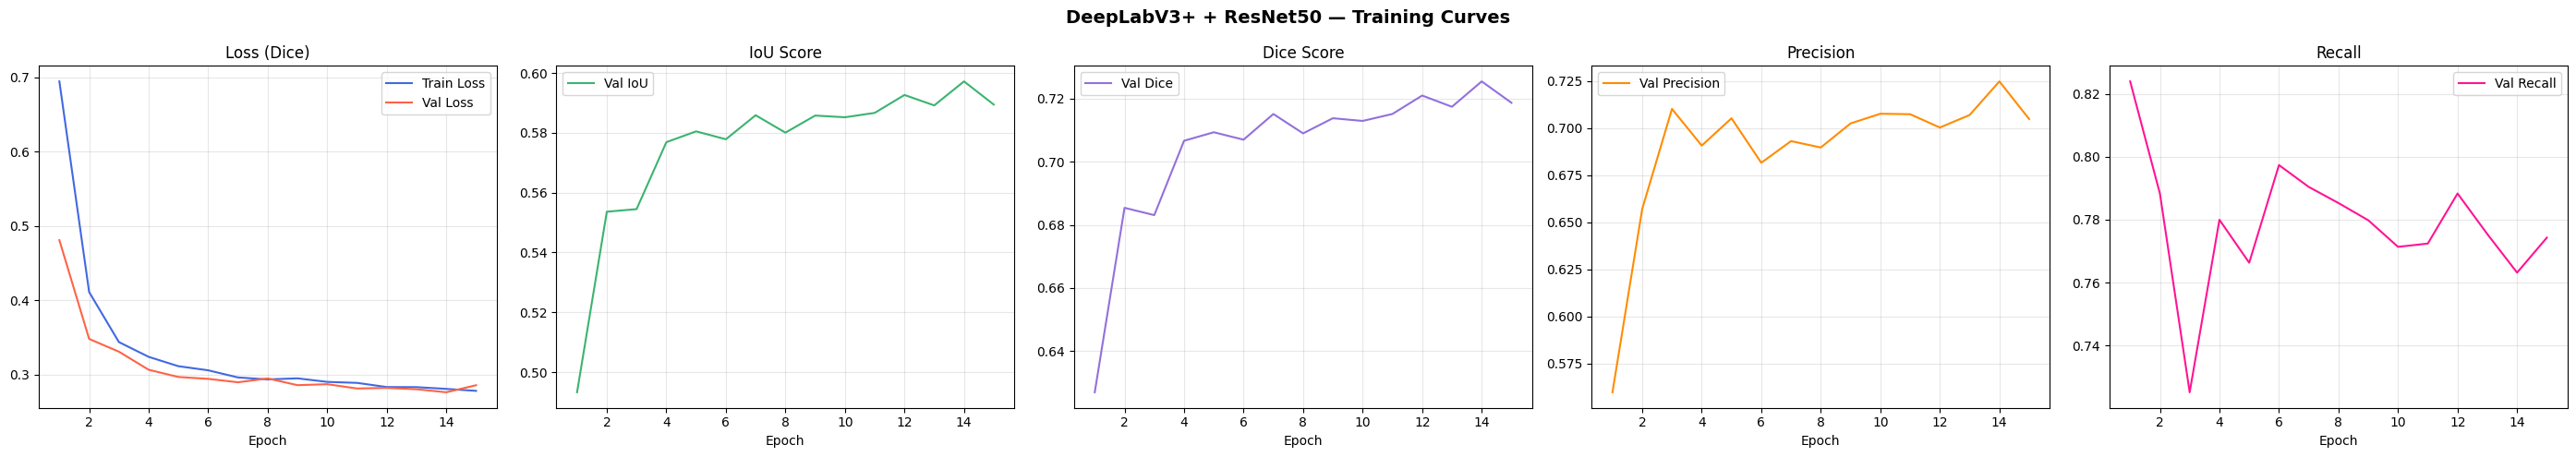

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
epochs2 = range(1, len(train_losses2) + 1)
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle("DeepLabV3+ + ResNet50 — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs2, train_losses2, label="Train Loss", color="royalblue")
axes[0].plot(epochs2, val_losses2,   label="Val Loss",   color="tomato")
axes[0].set_title("Loss (Dice)"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs2, val_ious2, label="Val IoU", color="mediumseagreen")
axes[1].set_title("IoU Score"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs2, val_dices2, label="Val Dice", color="mediumpurple")
axes[2].set_title("Dice Score"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(epochs2, val_precisions2, label="Val Precision", color="darkorange")
axes[3].set_title("Precision"); axes[3].set_xlabel("Epoch"); axes[3].legend(); axes[3].grid(alpha=0.3)

axes[4].plot(epochs2, val_recalls2, label="Val Recall", color="deeppink")
axes[4].set_title("Recall"); axes[4].set_xlabel("Epoch"); axes[4].legend(); axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model2_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Model Comparison

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
print(f"{'Model':<30} {'Dice':>8} {'IoU':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 66)
print(f"{'UNet + ResNet34':<30} {max(val_dices1):>8.4f} {max(val_ious1):>8.4f} {max(val_precisions1):>10.4f} {max(val_recalls1):>8.4f}")
print(f"{'DeepLabV3+ + ResNet50':<30} {max(val_dices2):>8.4f} {max(val_ious2):>8.4f} {max(val_precisions2):>10.4f} {max(val_recalls2):>8.4f}")

Model                              Dice      IoU  Precision   Recall
------------------------------------------------------------------
UNet + ResNet34                  0.7330   0.6063     0.7323   0.8612
DeepLabV3+ + ResNet50            0.7254   0.5972     0.7249   0.8239


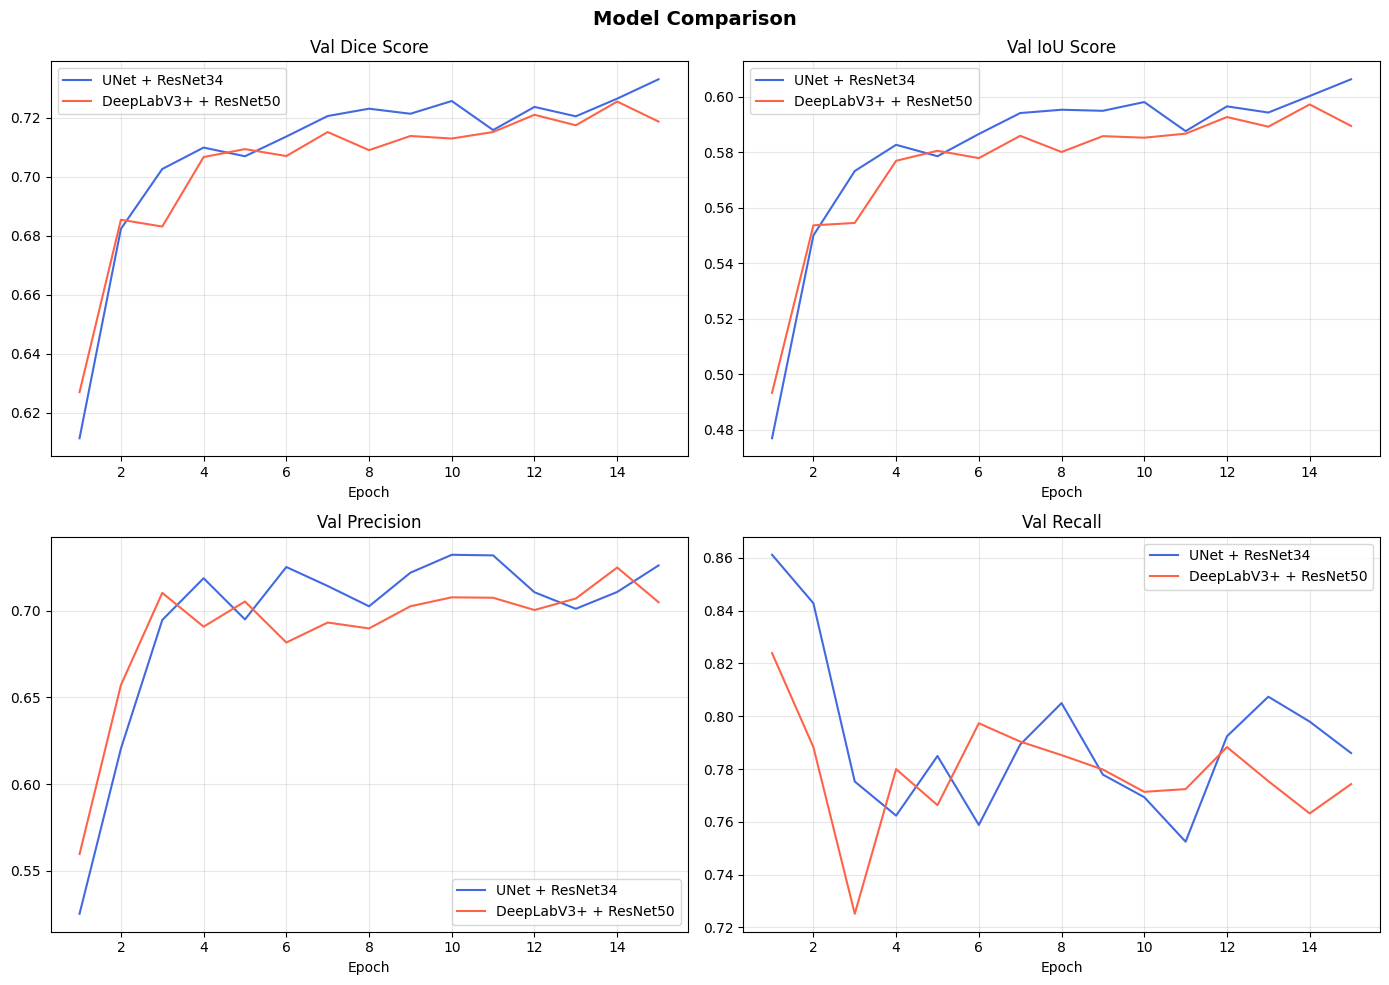

In [ ]:
# ── SKIP THIS CELL WHEN LOADING FROM DRIVE ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

axes[0][0].plot(range(1, len(val_dices1)+1), val_dices1, label="UNet + ResNet34",       color="royalblue")
axes[0][0].plot(range(1, len(val_dices2)+1), val_dices2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[0][0].set_title("Val Dice Score"); axes[0][0].set_xlabel("Epoch"); axes[0][0].legend(); axes[0][0].grid(alpha=0.3)

axes[0][1].plot(range(1, len(val_ious1)+1), val_ious1, label="UNet + ResNet34",       color="royalblue")
axes[0][1].plot(range(1, len(val_ious2)+1), val_ious2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[0][1].set_title("Val IoU Score"); axes[0][1].set_xlabel("Epoch"); axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

axes[1][0].plot(range(1, len(val_precisions1)+1), val_precisions1, label="UNet + ResNet34",       color="royalblue")
axes[1][0].plot(range(1, len(val_precisions2)+1), val_precisions2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[1][0].set_title("Val Precision"); axes[1][0].set_xlabel("Epoch"); axes[1][0].legend(); axes[1][0].grid(alpha=0.3)

axes[1][1].plot(range(1, len(val_recalls1)+1), val_recalls1, label="UNet + ResNet34",       color="royalblue")
axes[1][1].plot(range(1, len(val_recalls2)+1), val_recalls2, label="DeepLabV3+ + ResNet50", color="tomato")
axes[1][1].set_title("Val Recall"); axes[1][1].set_xlabel("Epoch"); axes[1][1].legend(); axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Inference — Predict Crack Mask for a New Image

In [18]:
# ── LOADING FROM DRIVE: set model path manually ──────────────────────────────
# If you just trained, comment the line below and uncomment the if/else block
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "model1_unet_resnet34.pth")
print(f"Best model path set to: {BEST_MODEL_PATH}")

# ── Uncomment below ONLY if you just finished training ───────────────────────
# if max(val_dices1) >= max(val_dices2):
#     BEST_MODEL_PATH = os.path.join(SAVE_DIR, "model1_unet_resnet34.pth")
#     print(f"Best model: UNet + ResNet34 (Dice: {max(val_dices1):.4f})")
# else:
#     BEST_MODEL_PATH = os.path.join(SAVE_DIR, "model2_deeplabv3plus_resnet50.pth")
#     print(f"Best model: DeepLabV3+ + ResNet50 (Dice: {max(val_dices2):.4f})")


Best model path set to: /content/outputs/model1_unet_resnet34.pth


In [19]:
best_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
best_model.to(device)
best_model.eval()
print(f"Model loaded from: {BEST_MODEL_PATH}")
print(f"Running on: {device}")

Model loaded from: /content/outputs/model1_unet_resnet34.pth
Running on: cuda


In [20]:
infer_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

def predict_mask(image_path: str, output_mask_path: str) -> str:

    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    original_h, original_w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    transformed = infer_transform(image=image_rgb)
    tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_model(tensor)
        pred   = (torch.sigmoid(output) > 0.5).float()

    mask = pred.squeeze().cpu().numpy()
    mask = (mask * 255).astype(np.uint8)
    mask = cv2.resize(mask, (original_w, original_h), interpolation=cv2.INTER_NEAREST)

    os.makedirs(os.path.dirname(output_mask_path), exist_ok=True)
    cv2.imwrite(output_mask_path, mask)
    print(f"[Inference] Mask saved → {output_mask_path}")
    return output_mask_path

[Inference] Mask saved → /content/outputs/outputs/sample_predicted_mask.png


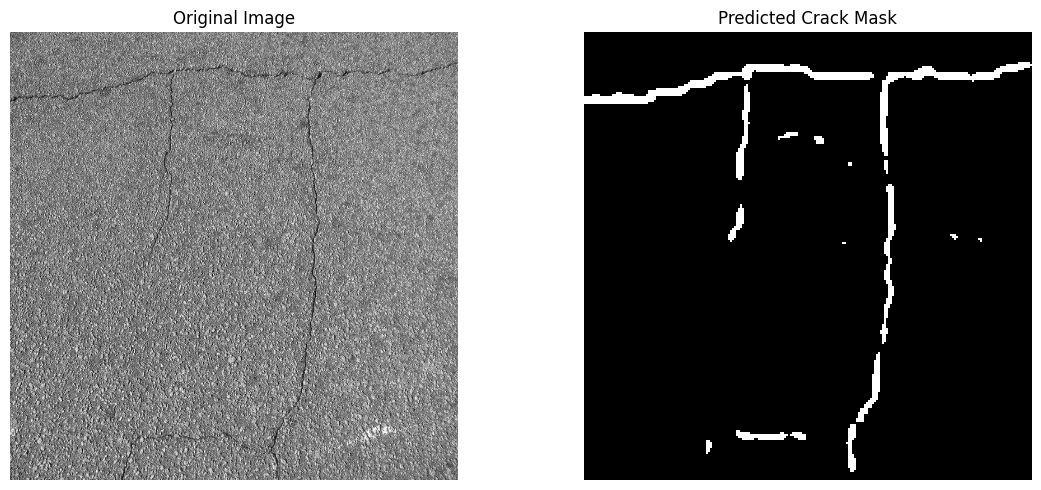

Visual check complete!


In [21]:
sample_image_path = os.path.join(image_dir, val_images[0])
sample_mask_path  = os.path.join(SAVE_DIR, "outputs", "sample_predicted_mask.png")

predict_mask(sample_image_path, sample_mask_path)

original  = cv2.cvtColor(cv2.imread(sample_image_path), cv2.COLOR_BGR2RGB)
pred_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original);               axes[0].set_title("Original Image");      axes[0].axis("off")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("Predicted Crack Mask"); axes[1].axis("off")
plt.tight_layout()
plt.show()
print("Visual check complete!")

## 13. Upload to Supabase Cloud Storage

In [22]:
pip install supabase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.9 MB/s eta 0:00:00


In [25]:
from supabase import create_client, Client
from pathlib import Path
from google.colab import userdata

# ── Load credentials from Colab Secrets ─────────────────────────────────────
# Add SUPABASE_URL and SUPABASE_KEY in Colab Secrets
SUPABASE_URL     = "https://lpazsslmpirwtfywndou.supabase.co"
SUPABASE_KEY     = userdata.get("SUPABASE_KEY")
BUCKET_ORIGINALS = "original-images"
BUCKET_MASKS     = "crack-masks"

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Supabase client ready!")

Supabase client ready!


In [26]:
def upload_to_bucket(local_path: str, bucket: str, remote_name: str) -> str:
    """Upload a file to a Supabase Storage bucket. Returns the public URL."""
    local_path   = Path(local_path)
    ext          = local_path.suffix.lower()
    content_type = "image/png" if ext == ".png" else "image/jpeg"

    with open(local_path, "rb") as f:
        file_bytes = f.read()

    supabase.storage.from_(bucket).upload(
        path=remote_name,
        file=file_bytes,
        file_options={"content-type": content_type, "upsert": "true"}
    )

    public_url = supabase.storage.from_(bucket).get_public_url(remote_name)
    return public_url


def push_inference_result(original_path: str, mask_path: str, image_id: str) -> dict:
    """
    Upload original image and predicted mask to Supabase.
    Returns handoff dict for Team Member 2 (Crack Metrics).
    """
    orig = Path(original_path)
    mask = Path(mask_path)

    orig_remote = f"{image_id}_original{orig.suffix}"
    mask_remote = f"{image_id}_mask{mask.suffix}"

    print(f"[Supabase] Uploading original → {orig_remote}")
    original_url = upload_to_bucket(original_path, BUCKET_ORIGINALS, orig_remote)
    print(f"[Supabase] ✓ Original uploaded")

    print(f"[Supabase] Uploading mask    → {mask_remote}")
    mask_url = upload_to_bucket(mask_path, BUCKET_MASKS, mask_remote)
    print(f"[Supabase] ✓ Mask uploaded")

    result = {
        "image_id":     image_id,
        "original_url": original_url,
        "mask_url":     mask_url
    }

    print(f"\n[Supabase] Handoff ready:")
    print(f"           image_id     → {image_id}")
    print(f"           original_url → {original_url}")
    print(f"           mask_url     → {mask_url}")
    return result

In [27]:
import uuid

INPUT_IMAGE_PATH = sample_image_path
OUTPUT_MASK_PATH = os.path.join(SAVE_DIR, "outputs", "final_predicted_mask.png")

predict_mask(INPUT_IMAGE_PATH, OUTPUT_MASK_PATH)

image_id = str(uuid.uuid4())
result   = push_inference_result(INPUT_IMAGE_PATH, OUTPUT_MASK_PATH, image_id)

handoff_path = os.path.join(SAVE_DIR, "handoff.json")
with open(handoff_path, "w") as f:
    json.dump(result, f, indent=2)

print(f"\n[Pipeline] handoff.json saved → {handoff_path}")
print("[Pipeline] Full pipeline complete!")
print(json.dumps(result, indent=2))

[Inference] Mask saved → /content/outputs/outputs/final_predicted_mask.png
[Supabase] Uploading original → 58471d00-89bc-4b03-8c7b-f39adcddd80a_original.jpg
[Supabase] ✓ Original uploaded
[Supabase] Uploading mask    → 58471d00-89bc-4b03-8c7b-f39adcddd80a_mask.png
[Supabase] ✓ Mask uploaded

[Supabase] Handoff ready:
           image_id     → 58471d00-89bc-4b03-8c7b-f39adcddd80a
           original_url → https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/original-images/58471d00-89bc-4b03-8c7b-f39adcddd80a_original.jpg
           mask_url     → https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/crack-masks/58471d00-89bc-4b03-8c7b-f39adcddd80a_mask.png

[Pipeline] handoff.json saved → /content/outputs/handoff.json
[Pipeline] Full pipeline complete!
{
  "image_id": "58471d00-89bc-4b03-8c7b-f39adcddd80a",
  "original_url": "https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/original-images/58471d00-89bc-4b03-8c7b-f39adcddd80a_original.jpg",
  "

## 14. Pipeline Entry Point (for Streamlit Integration)

In [28]:
def run_pipeline(input_image_path: str, output_dir: str = "/content/outputs") -> dict:
    """
    Full pipeline entry point.
    Input:  path to a user-uploaded infrastructure image
    Output: handoff dict with image_id, original_url, mask_url
    """
    try:
        # Validate image exists
        if not os.path.exists(input_image_path):
            raise FileNotFoundError(f"Image not found: {input_image_path}")

        # Validate image is readable
        test = cv2.imread(input_image_path)
        if test is None:
            raise ValueError(f"Image could not be read, check format: {input_image_path}")

        os.makedirs(output_dir, exist_ok=True)
        image_id         = str(uuid.uuid4())
        output_mask_path = os.path.join(output_dir, f"{image_id}_mask.png")

        # Step 1: Generate mask
        predict_mask(input_image_path, output_mask_path)

        # Step 2: Upload to Supabase
        result = push_inference_result(input_image_path, output_mask_path, image_id)

        # Step 3: Save handoff
        with open(os.path.join(output_dir, f"{image_id}_handoff.json"), "w") as f:
            json.dump(result, f, indent=2)

        return result

    except FileNotFoundError as e:
        print(f"[Pipeline Error] File not found: {e}")
        raise
    except ValueError as e:
        print(f"[Pipeline Error] Invalid image: {e}")
        raise
    except Exception as e:
        print(f"[Pipeline Error] Something went wrong: {e}")
        raise

In [29]:
result = run_pipeline(sample_image_path)
print(result)

[Inference] Mask saved → /content/outputs/83400b76-e8d0-4602-8e10-ab247b3f29e4_mask.png
[Supabase] Uploading original → 83400b76-e8d0-4602-8e10-ab247b3f29e4_original.jpg
[Supabase] ✓ Original uploaded
[Supabase] Uploading mask    → 83400b76-e8d0-4602-8e10-ab247b3f29e4_mask.png
[Supabase] ✓ Mask uploaded

[Supabase] Handoff ready:
           image_id     → 83400b76-e8d0-4602-8e10-ab247b3f29e4
           original_url → https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/original-images/83400b76-e8d0-4602-8e10-ab247b3f29e4_original.jpg
           mask_url     → https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/crack-masks/83400b76-e8d0-4602-8e10-ab247b3f29e4_mask.png
{'image_id': '83400b76-e8d0-4602-8e10-ab247b3f29e4', 'original_url': 'https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/original-images/83400b76-e8d0-4602-8e10-ab247b3f29e4_original.jpg', 'mask_url': 'https://lpazsslmpirwtfywndou.supabase.co/storage/v1/object/public/crack-masks/83